In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import joblib
import warnings
import os

warnings.filterwarnings('ignore')

# Проверка устройства для ускорения (GPU / Apple Silicon / CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    
print(f"🚀 Используемое устройство: {device}")

🚀 Используемое устройство: mps


In [2]:
print("Загрузка финального объединенного датасета...")
df = pd.read_parquet("../data/processed/full_merged_dataset.parquet")

SEQ_LEN = 32          # Длина окна (сколько свечей видит модель)
FORWARD_HORIZON = 4   # Предсказываем на 4 свечи вперед (1 час)

# 1. Создаем Target (1 - если цена выросла, 0 - если упала)
df['future_return'] = np.log(df['close'].shift(-FORWARD_HORIZON) / df['close'])

# 2. Фичи: 12 Технических + 384 Макро
top_tech_features = [
    "rsi", "premium_discount", "dist_to_liq_high", "dist_to_liq_low", 
    "struct_trend", "Norm_Slope", "dist_to_pdh", "fvg_bear_size", 
    "fvg_bull_size", "dist_to_pdl", "trend_1h", "mtfa_score"
]
macro_cols = [f'macro_emb_{i}' for i in range(384)]
feature_cols = top_tech_features + macro_cols

# 3. Очистка перед обучением
df_clean = df[['future_return'] + feature_cols].copy()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.dropna(inplace=True) # Удаляем последние 4 свечи из-за shift(-4)

targets = (df_clean['future_return'] > 0).astype(int).values

print(f"Размерность датасета: {df_clean.shape}")

Загрузка финального объединенного датасета...
Размерность датасета: (644214, 397)


In [3]:
# 1. СЖАТИЕ МАКРО-ДАННЫХ (PCA)
print("Сжатие 384 макро-векторов в 8 главных компонент...")
pca = PCA(n_components=8)
macro_compressed = pca.fit_transform(df_clean[macro_cols].values)

# 2. Сборка и Масштабирование (12 тех + 8 макро = 20 фичей)
tech_features_array = df_clean[top_tech_features].values
combined_features = np.hstack([tech_features_array, macro_compressed])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_features)

# 3. ПОИСК СОБЫТИЙ (Event-Based Sampling)
# Мы хотим, чтобы модель училась на ситуациях, когда выходит новость
macro_changes = df_clean['macro_emb_0'].diff().abs() > 0
macro_changes.iloc[0] = True 
event_indices = np.where(macro_changes)[0]

print(f"Найдено {len(event_indices)} макро-событий. Нарезаем 3D-окна...")

X_events, y_events = [], []
for idx in event_indices:
    # [ИСПРАВЛЕНО]: Окно ДОЛЖНО включать свечу самой новости (idx + 1)
    if idx >= (SEQ_LEN - 1) and idx < len(scaled_features) - FORWARD_HORIZON:
        X_events.append(scaled_features[idx - SEQ_LEN + 1 : idx + 1])
        y_events.append(targets[idx])

X_events = np.array(X_events)
y_events = np.array(y_events)

# Разделение на Train и Test (Без перемешивания, чтобы соблюсти хронологию!)
split_idx = int(len(X_events) * 0.8)
train_features, train_targets = X_events[:split_idx], y_events[:split_idx]
test_features, test_targets = X_events[split_idx:], y_events[split_idx:]

print(f"Train: {len(train_features)} событий | Test: {len(test_features)} событий")

Сжатие 384 макро-векторов в 8 главных компонент...
Найдено 543 макро-событий. Нарезаем 3D-окна...
Train: 433 событий | Test: 109 событий


In [4]:
class QuantEventDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(QuantEventDataset(train_features, train_targets), batch_size=32, shuffle=True)
test_loader = DataLoader(QuantEventDataset(test_features, test_targets), batch_size=32, shuffle=False)

class Quantformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super(Quantformer, self).__init__()
        self.feature_projection = nn.Linear(num_features, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, 
            batch_first=True, dropout=0.2
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc_out = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) # Логит для бинарной классификации
        )

    def forward(self, x):
        x = self.feature_projection(x)
        trans_out = self.transformer(x)
        last_step_out = trans_out[:, -1, :] 
        return self.fc_out(last_step_out)

model = Quantformer(num_features=train_features.shape[2]).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

print("Модель готова к обучению!")

Модель готова к обучению!


Epoch 1/15 | Train Loss: 0.6878 | Test Loss: 0.6972 | Test Hit Rate: 53.21%
Epoch 2/15 | Train Loss: 0.6780 | Test Loss: 0.6972 | Test Hit Rate: 52.29%
Epoch 3/15 | Train Loss: 0.6635 | Test Loss: 0.6943 | Test Hit Rate: 52.29%
Epoch 4/15 | Train Loss: 0.6651 | Test Loss: 0.6981 | Test Hit Rate: 53.21%
Epoch 5/15 | Train Loss: 0.6507 | Test Loss: 0.6919 | Test Hit Rate: 50.46%
Epoch 6/15 | Train Loss: 0.6490 | Test Loss: 0.6927 | Test Hit Rate: 48.62%
Epoch 7/15 | Train Loss: 0.6298 | Test Loss: 0.6892 | Test Hit Rate: 50.46%
Epoch 8/15 | Train Loss: 0.6182 | Test Loss: 0.6884 | Test Hit Rate: 51.38%
Epoch 9/15 | Train Loss: 0.6104 | Test Loss: 0.6983 | Test Hit Rate: 51.38%
Epoch 10/15 | Train Loss: 0.5875 | Test Loss: 0.7016 | Test Hit Rate: 53.21%
Epoch 11/15 | Train Loss: 0.5750 | Test Loss: 0.6948 | Test Hit Rate: 56.88%
Epoch 12/15 | Train Loss: 0.5607 | Test Loss: 0.6974 | Test Hit Rate: 55.96%
Epoch 13/15 | Train Loss: 0.5444 | Test Loss: 0.7083 | Test Hit Rate: 53.21%
Epoch 14

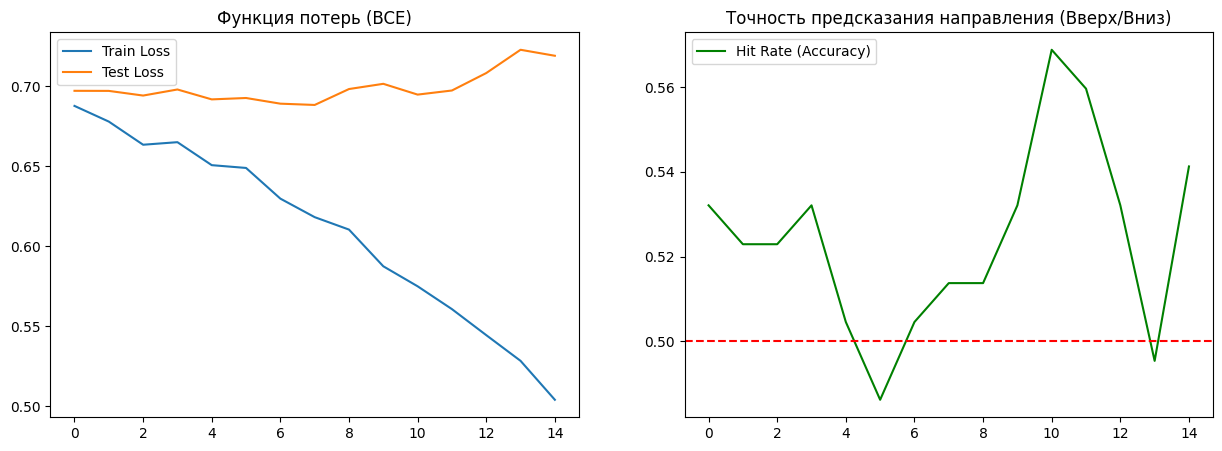

In [5]:
EPOCHS = 15
train_losses, test_losses = [], []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Валидация (Тест)
    model.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_test_loss += loss.item()
            
            # Считаем Hit Rate (Сигмоида переводит Logit в вероятность)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
            
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    hit_rate = correct / total
    test_accuracies.append(hit_rate)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Hit Rate: {hit_rate:.2%}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_title("Функция потерь (BCE)")
ax1.legend()

ax2.plot(test_accuracies, label='Hit Rate (Accuracy)', color='green')
ax2.axhline(0.5, color='red', linestyle='--')
ax2.set_title("Точность предсказания направления (Вверх/Вниз)")
ax2.legend()
plt.show()

In [6]:
target_dir = "../data/processed"
os.makedirs(target_dir, exist_ok=True)

# Сохраняем веса, скейлер и PCA-трансформер, чтобы us_agent.py мог ими пользоваться
torch.save(model.state_dict(), f"{target_dir}/us_quantformer.pth")
joblib.dump(scaler, f"{target_dir}/us_scaler.pkl")
joblib.dump(pca, f"{target_dir}/us_pca.pkl")

print("✅ Артефакты Агента США успешно сохранены!")

✅ Артефакты Агента США успешно сохранены!
